### Import Everything

In [1]:
import praw
import os
from dotenv import load_dotenv
from tickers.processTickers import getTickers
import pandas as pd
from datetime import datetime, UTC
import yfinance as yf
import matplotlib.pyplot as plt

load_dotenv()

True

### Create Reddit Connection

In [2]:
reddit = praw.Reddit(
    client_id=os.getenv("CLIENT_ID"),
    client_secret=os.getenv("CLIENT_SECRET"),
    user_agent="ratem/0.1 by tkofb"
)

Version 7.7.1 of praw is outdated. Version 7.8.1 was released Friday October 25, 2024.


### Update or Obtain Tickers

In [3]:
tickers = getTickers()
tickerSet = set(tickers['Symbol'])

### Populate Set of Users

In [4]:
userSet = set()
subreddit = reddit.subreddit("pennystocks")

for post in subreddit.hot(limit=100):
    userSet.add(post.author)

### Track Reddit User Post Stock Picks

In [5]:
def processUserStocks(username, stocksLen, stocks_df):
    redditor = reddit.redditor(username)
    print(f"Current User: {username}")
    
    # Can also be .top() or .hot() [Think about what you prefer]
    for post in redditor.submissions.new(limit=10):
        # Want to focus only on penny stocks subreddit for now
        post_date = datetime.fromtimestamp(post.created_utc, UTC)
        
        if post.subreddit == 'pennystocks':
            if post.is_self:
                currPost = post.selftext
                currPostSet = set(currPost.split()).union(set(post.title.split()))
                buyOrSell = 'BUY'
    
                for elem in currPostSet:
                    
                    

                    if elem[0] == "$":
                        elem = elem.upper()
                        elem = elem[1:]
                    
                    if elem in tickerSet:
                        stocks_df.loc[stocksLen] = [username, elem, post_date, datetime.now(UTC), buyOrSell]
                        stocksLen += 1
    

    return stocksLen

In [6]:
stocks = pd.DataFrame(columns=['Username','Symbol', 'Start Date', 'End Date', 'Buy Or Sell'])
currLen = 0

for user in userSet:
    if user is not None:
        currLen = processUserStocks(user.name, currLen, stocks)

stocks

Current User: FineShape6138
Current User: TradeSpecialist7972
Current User: PennyworthInvesting
Current User: Front-Page_News
Current User: dromance
Current User: Capitalpopcorn
Current User: New-Tadpole-3971
Current User: Senior-Purchase-538
Current User: AttentionFormer4098
Current User: OkParamedic5656
Current User: Patient-Craft-1944
Current User: pristinegazeinc
Current User: Impossible-Hair1343
Current User: West-Historian-8754
Current User: Old-Pomegranate3634
Current User: Sudden-Bother-4087
Current User: FlashZerro
Current User: marshall_tony
Current User: thesatisfiedplethora
Current User: Environmental-Meal14
Current User: Routine_One_4016
Current User: MightBeneficial3302
Current User: GreatWhiteBuffalo99
Current User: Physical-Squirrel-40
Current User: PennyBotWeekly
Current User: landspeed
Current User: obbe57
Current User: PuzzleheadedPhoto272
Current User: La_Trova_2021
Current User: Kuentai
Current User: Smart-Material-4832
Current User: fluahaa
Current User: naimirix


,Username,Symbol,Start Date,End Date,Buy Or Sell
0,Front-Page_News,BURU,2025-02-28 19:30:33+00:00,2025-02-28 19:55:33.788494+00:00,BUY
1,dromance,BTAI,2025-02-28 15:22:23+00:00,2025-02-28 19:55:34.093850+00:00,BUY
2,dromance,IBD,2025-02-25 13:53:41+00:00,2025-02-28 19:55:34.095444+00:00,BUY
3,dromance,FXR,2025-02-25 13:53:41+00:00,2025-02-28 19:55:34.096375+00:00,BUY
4,dromance,ONVO,2025-02-25 13:53:41+00:00,2025-02-28 19:55:34.097173+00:00,BUY
...,...,...,...,...,...
201,keenomatic,EV,2025-02-27 08:07:52+00:00,2025-02-28 19:55:53.146799+00:00,BUY
202,keenomatic,NPV,2025-02-27 08:07:52+00:00,2025-02-28 19:55:53.148680+00:00,BUY
203,keenomatic,EU,2025-02-27 08:07:52+00:00,2025-02-28 19:55:53.150546+00:00,BUY
204,keenomatic,EU,2025-02-26 16:25:42+00:00,2025-02-28 19:55:53.152588+00:00,BUY


Symbol
SPGC    6
USA     5
EU      5
LITM    5
STAI    4
PDSB    4
CA      4
PACB    3
CFO     3
GSM     3
SYTA    3
VLCN    3
UPS     3
AMPX    3
RVSN    3
TRNR    3
PDS     3
SKYX    3
EPS     3
UBS     3
Name: count, dtype: int64

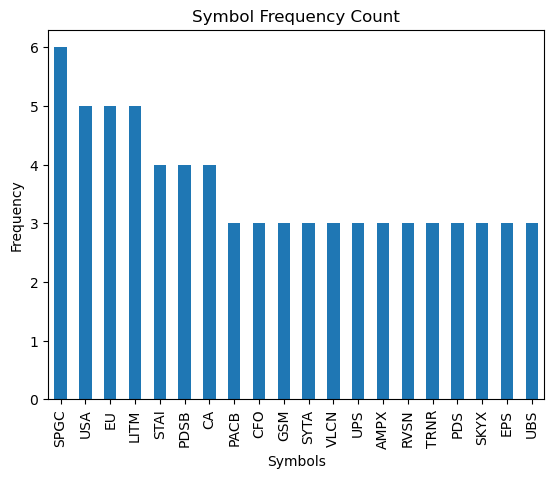

In [7]:
frequency_plot = stocks['Symbol'].value_counts().head(20)
display(frequency_plot)
frequency_plot.plot(kind='bar')

# Add labels and title
plt.xlabel('Symbols')
plt.ylabel('Frequency')
plt.title('Symbol Frequency Count')

# Show plot
plt.show()